## 1. Introduction

Hospital readmission within 30 days of discharge is costly and hospitals are financially penalised for it, so flagging at-risk patients at discharge has clear clinical value.

This notebook covers the EDA and data preparation for the *Diabetes 130-US Hospitals for years 1999-2008* dataset (UCI ID 296): 101,766 inpatient encounters of diabetic patients across 50 columns - demographics, admission/discharge codes, lab and procedure counts, ICD-9 diagnoses, 23 medication columns and the `readmitted` outcome.

The raw `readmitted` column has three levels: `NO` (54,864), `>30` (35,545) and `<30` (11,357). We model it as a binary target, `readmitted_30d = 1` when `readmitted == '<30'` and 0 otherwise, which gives 11,357 / 101,766 = **11.16% positive**. That imbalance drives several later choices: stratified splitting, deferring resampling to the modelling stage, and not judging models on accuracy alone.

A single random seed, `RANDOM_STATE = 42`, is fixed and reused throughout.

## 2. Data loading and first inspection

**Import required libraries**

In [1]:
# Core data-handling and plotting stack (pandas / numpy / matplotlib / seaborn), plus
import json
import warnings
from io import StringIO
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# silence benign FutureWarning/DeprecationWarning noise from the
warnings.filterwarnings("ignore")

# Global random seed - fixed once and reused everywhere in this notebook (splits, imputation is deterministic so no
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Resolve the project root so the notebook runs correctly whether it is launched from the project root or from inside
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)

.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Load the raw data**

First inspection with `shape`, `info()`, `head()` and `describe()`, before any cleaning decision is made.

In [2]:
# First pass: read the file exactly as shipped, with no na_values override yet. `low_memory = False` avoids pandas'
data = pd.read_csv(DATA_DIR / "diabetic_data.csv", low_memory=False)
data.shape

(101766, 50)

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [4]:
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


**Missing values are hidden behind two different sentinels**

`df.isnull().sum()` on the raw file reports almost nothing, because missingness is encoded two different ways.

*Trap 1 - the `'?'` sentinel.* Most genuinely missing values are stored as the literal string `'?'`, which pandas treats as an ordinary category rather than `NaN`. The true extent shows up with `(data == '?').sum()`; the fix is to re-read with `na_values='?'`.

*Trap 2 - the lab-result columns.* `max_glu_serum` and `A1Cresult` use `"None"` to mean the test was never ordered, which is information rather than a missing value. `"None"` is already in pandas' default `na_values`, and `na_values='?'` adds to that default rather than replacing it, so `"None"` is still turned into `NaN`. Imputing those cells would assert a lab result for ~90% of patients who were never tested, so we restore `"Not tested"` as an explicit category.

In [6]:
# What the taught detector reports on the raw file: almost nothing, because '?' is not NaN.
print("isnull() total across the whole frame:", data.isnull().sum().sum())
data.isnull().sum()[data.isnull().sum() > 0]

isnull() total across the whole frame: 181168


max_glu_serum    96420
A1Cresult        84748
dtype: int64

In [7]:
# The '?' sentinel, made visible by checking for the literal string instead.
question_mark_counts = (data == "?").sum()
question_mark_counts = question_mark_counts[question_mark_counts > 0].sort_values(ascending=False)
question_mark_pct = (question_mark_counts / len(data) * 100).round(2)
pd.DataFrame({"n_question_marks": question_mark_counts, "pct_of_rows": question_mark_pct})

,n_question_marks,pct_of_rows
weight,98569,96.86
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


In [8]:
# Fix: re-read the file telling pandas that '?' is the missing-value sentinel. Every
# analysis from this point on uses this corrected frame.
data = pd.read_csv(DATA_DIR / "diabetic_data.csv", na_values="?", low_memory=False)

# Second, subtler NA trap: the-result columns ---------------------------- `A1Cresult` and `max_glu_serum` use the
clinical_test_cols = ["A1Cresult", "max_glu_serum"]
for col in clinical_test_cols:
    data[col] = data[col].fillna("Not tested")

print("Restored 'Not tested' as an explicit category (test not ordered != missing):")
for col in clinical_test_cols:
    print(f"  {col}: {data[col].value_counts().to_dict()}")

# Confirm the fix: isnull now sees the '?' columns too, at the same counts computed
# above - and the two clinical-test columns correctly no longer appear as missing.
missing_pct = (data.isnull().sum() / len(data) * 100).round(2)
missing_pct[missing_pct > 0].sort_values(ascending=False)

Restored 'Not tested' as an explicit category (test not ordered != missing):
  A1Cresult: {'Not tested': 84748, '>8': 8216, 'Norm': 4990, '>7': 3812}
  max_glu_serum: {'Not tested': 96420, 'Norm': 2597, '>200': 1485, '>300': 1264}


weight               96.86
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64

> **Modernisation note.** Under pandas 3.0's new default string backend, the 37 non-numeric
> columns above load with dtype `str` rather than the pre-3.0 `object`. `select_dtypes` still
> accepts `include = "object"` for backward compatibility (with a deprecation warning), so we
> use `select_dtypes(exclude = "number")` throughout this notebook to select categorical
> columns without triggering it.

## 3. Exploratory Data Analysis

Univariate, bivariate/multivariate, and an automated pass. Related plots are grouped into composite figures rather than one per column.

### 3.1 Univariate analysis

**Numeric features — histograms**

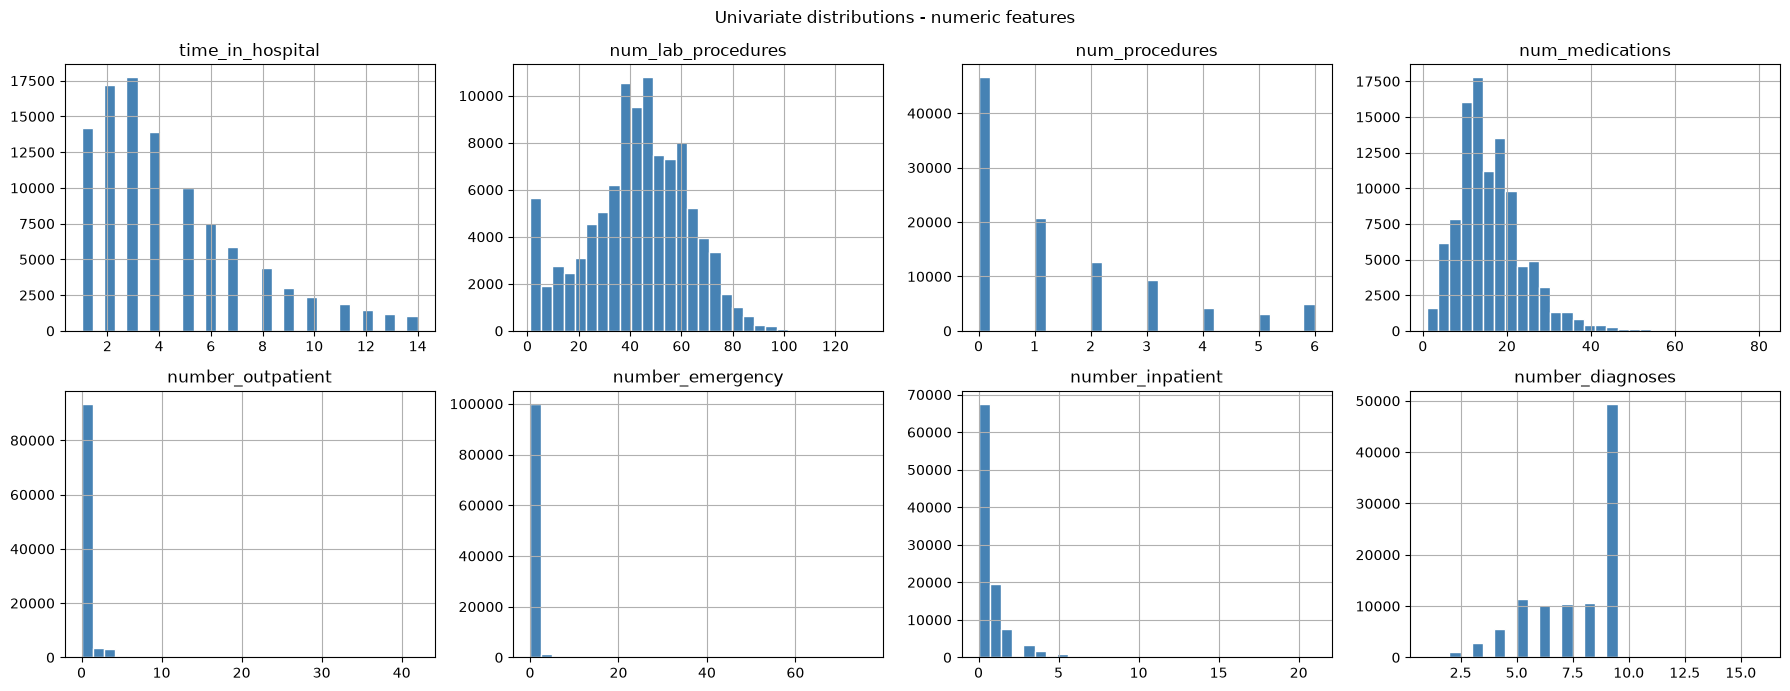

In [9]:
# The natural numeric IVs (encounter_id and patient_nbr are identifiers, not measurements
# so they are excluded from this and every subsequent numeric summary).
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    data[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Univariate distributions - numeric features")
plt.tight_layout()
plt.show()

**Numeric features — boxplots**

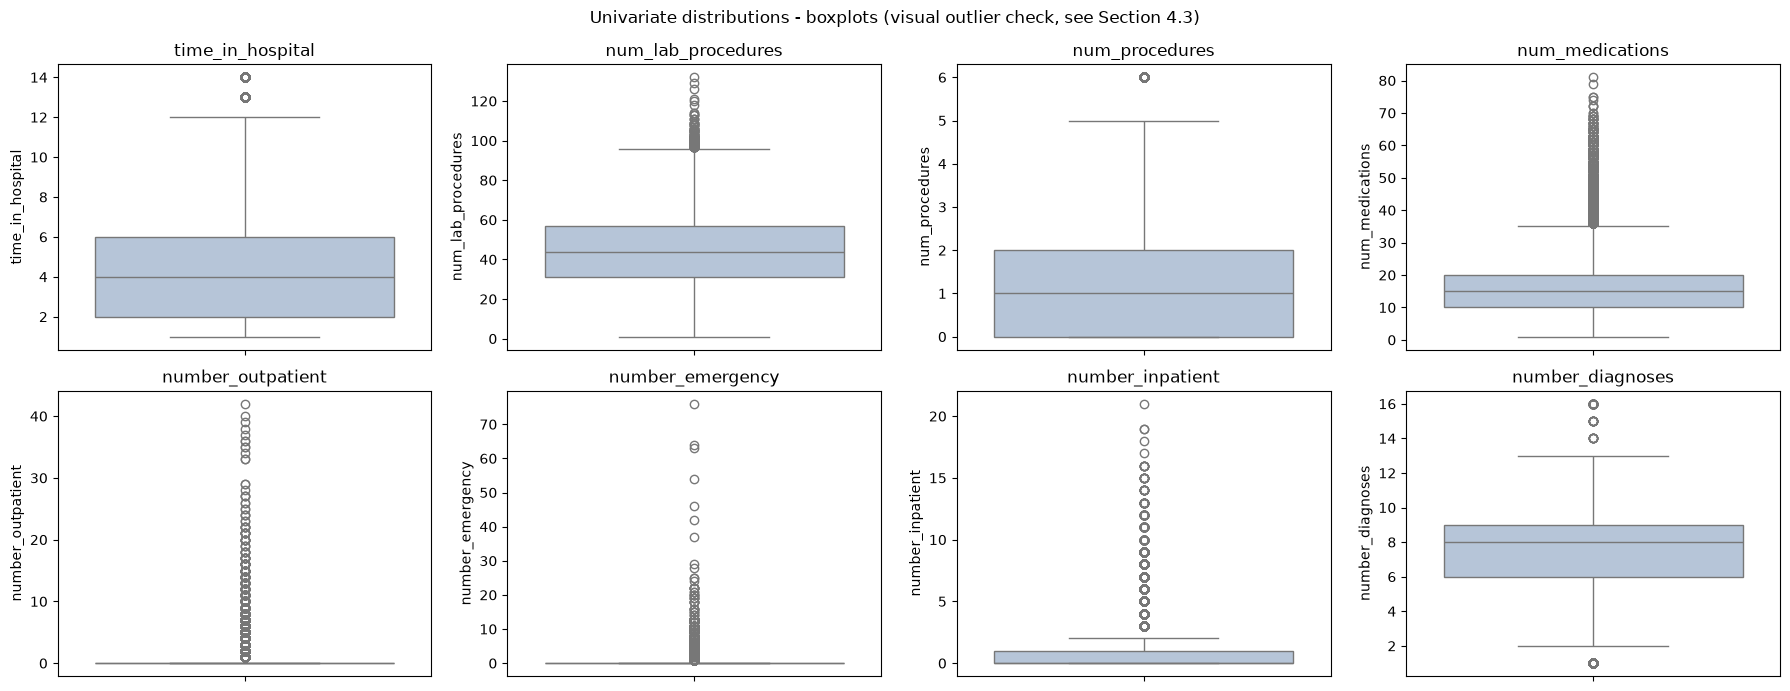

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(y=data[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
plt.suptitle("Univariate distributions - boxplots (visual outlier check, see Section 4.3)")
plt.tight_layout()
plt.show()

**Categorical features - value counts and bar plots**

A representative subset: demographics, admission type, and the two lab-test result columns.

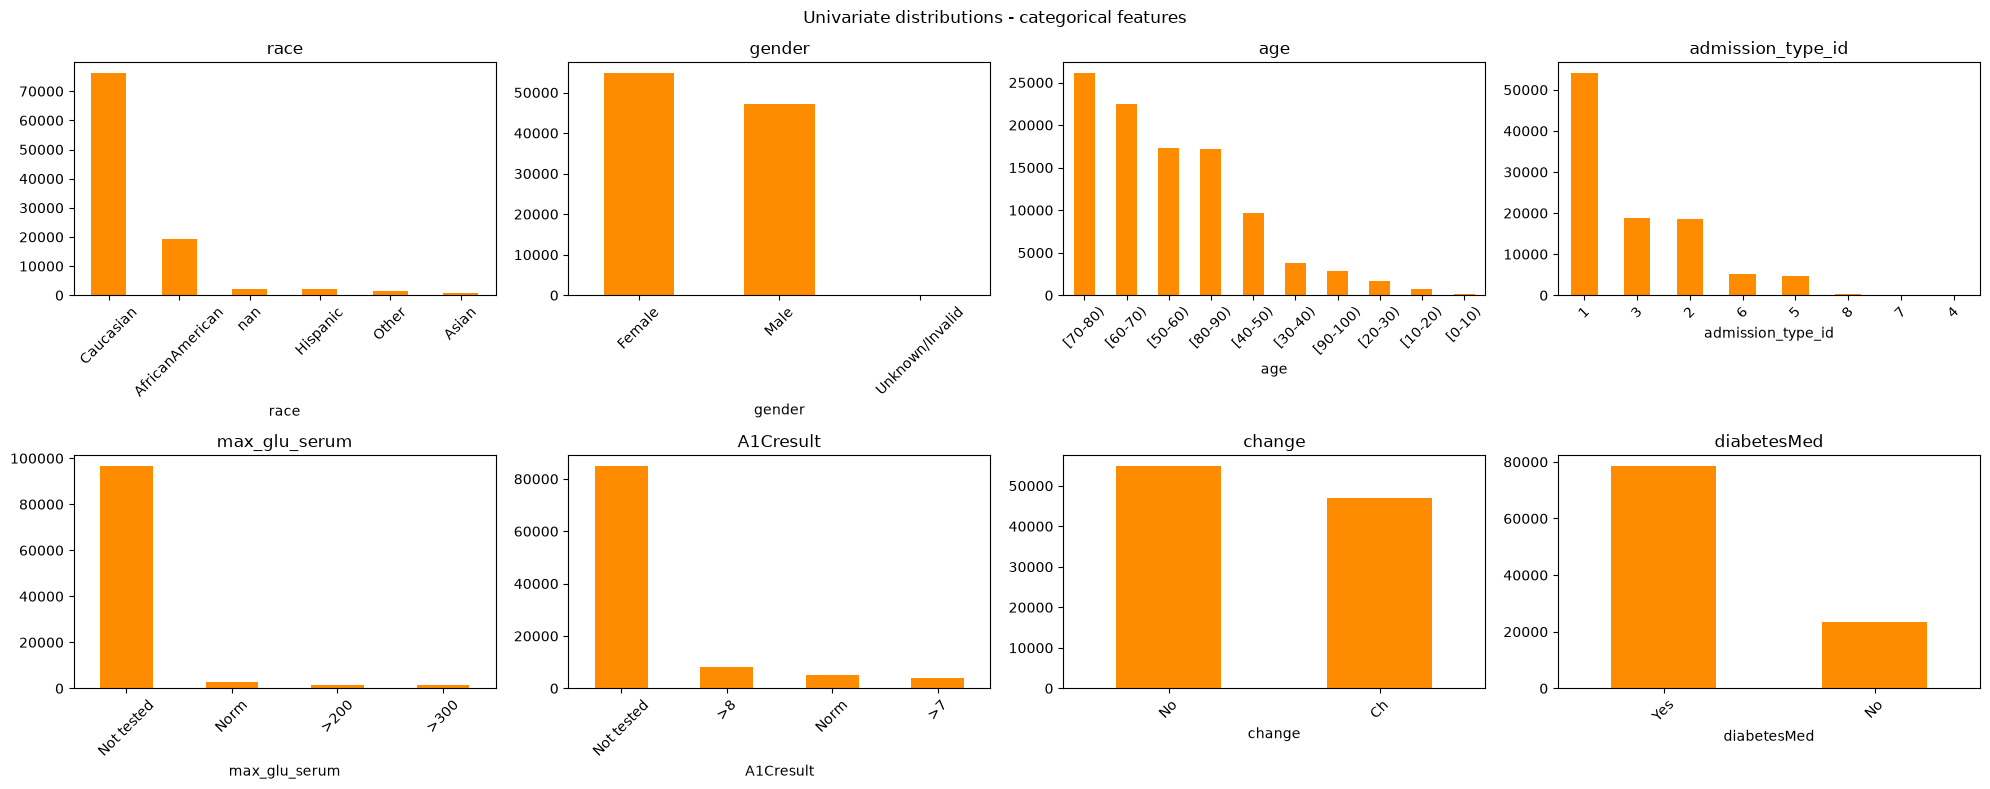

In [11]:
categorical_preview_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), categorical_preview_cols):
    data[col].value_counts(dropna=False).plot(kind="bar", ax=ax, color="darkorange")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("Univariate distributions - categorical features")
plt.tight_layout()
plt.show()

### 3.2 Bivariate / multivariate analysis

**Correlation heatmap (numeric features)**

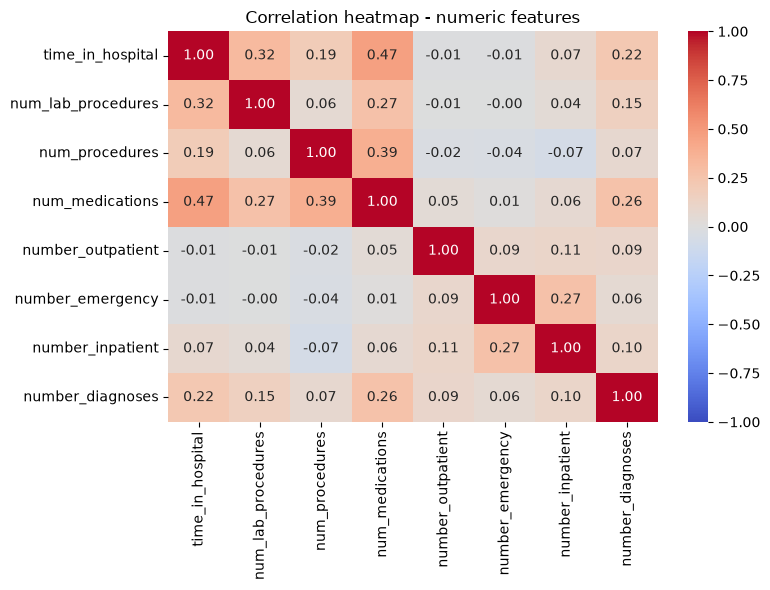

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap - numeric features")
plt.tight_layout()
plt.show()

**Key numerics split by target**

`readmitted_30d` is built in Section 5; a temporary preview copy is used here only for plotting and is discarded afterwards.

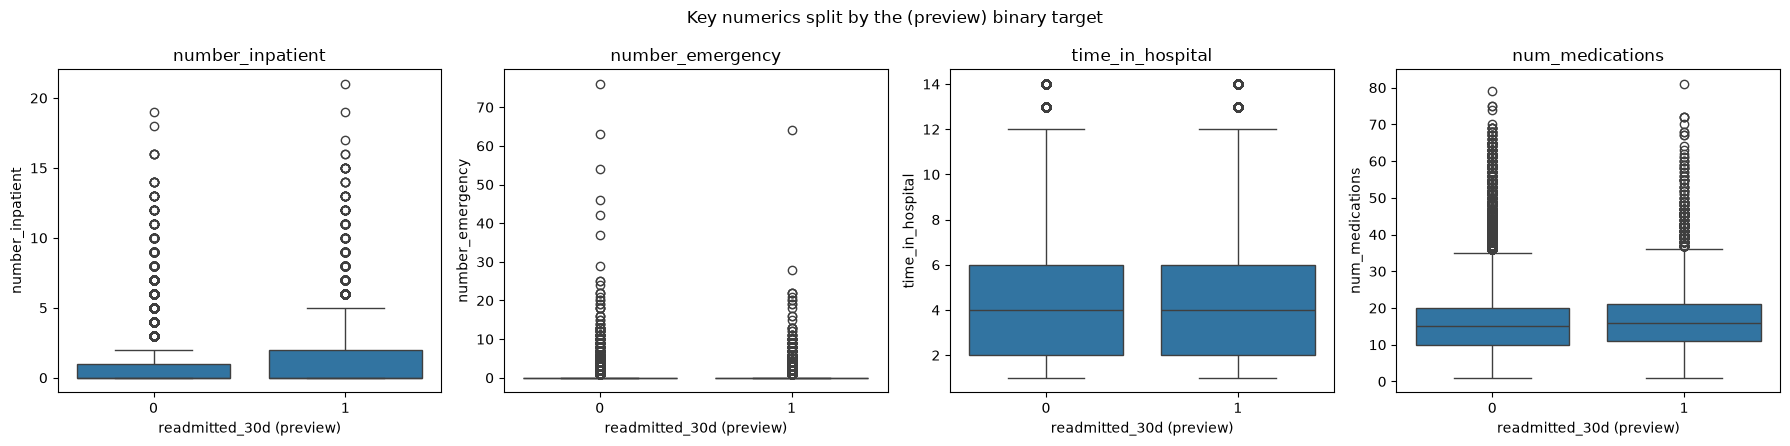

In [13]:
_target_preview = (data["readmitted"] == "<30").astype(int)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes.ravel(), ["number_inpatient", "number_emergency", "time_in_hospital", "num_medications"]):
    sns.boxplot(x=_target_preview, y=data[col], ax=ax)
    ax.set_xlabel("readmitted_30d (preview)")
    ax.set_title(col)
plt.suptitle("Key numerics split by the (preview) binary target")
plt.tight_layout()
plt.show()

**Key categoricals vs target — crosstabs**

In [14]:
# Row-normalised crosstab: within each age band, what fraction is a <30-day readmission?
age_vs_target = pd.crosstab(data["age"], _target_preview, normalize="index") * 100
age_vs_target.columns = ["not_readmitted_30d_pct", "readmitted_30d_pct"]
age_vs_target

,not_readmitted_30d_pct,readmitted_30d_pct
age,,
[0-10),98.136646,1.863354
[10-20),94.211288,5.788712
[20-30),85.757393,14.242607
[30-40),88.768212,11.231788
[40-50),89.395973,10.604027
[50-60),90.333797,9.666203
[60-70),88.871592,11.128408
[70-80),88.226945,11.773055
[80-90),87.916497,12.083503


In [15]:
admission_type_vs_target = pd.crosstab(data["admission_type_id"], _target_preview, normalize="index") * 100
admission_type_vs_target.columns = ["not_readmitted_30d_pct", "readmitted_30d_pct"]
admission_type_vs_target.sort_values("readmitted_30d_pct", ascending=False)

,not_readmitted_30d_pct,readmitted_30d_pct
admission_type_id,,
1,88.477496,11.522504
2,88.820346,11.179654
6,88.924589,11.075411
3,89.607292,10.392708
5,89.655172,10.344828
4,90.000000,10.000000
8,91.562500,8.437500
7,100.000000,0.000000


In [16]:
# Clean up the preview-only variable so it cannot be mistaken for the real target later.
del _target_preview

### 3.3 Target distribution and the imbalance

In [17]:
print(data["readmitted"].value_counts())
print()
print((data["readmitted"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     53.91 %
>30    34.93 %
<30    11.16 %
Name: proportion, dtype: str


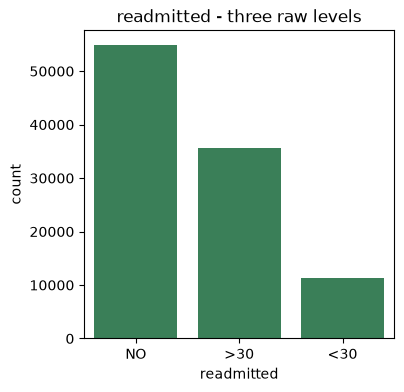

In [18]:
plt.figure(figsize=(4, 4))
sns.countplot(x=data["readmitted"], order=["NO", ">30", "<30"], color="seagreen")
plt.title("readmitted - three raw levels")
plt.show()

Collapsing to the binary target (`<30` = 1, else 0) gives 11,357 / 101,766 = **11.16% positive**, a substantially imbalanced problem that is carried through the split, the resampling policy and the metric choices.

### 3.4 Automated EDA with Sweetviz

Sweetviz is run over the `'?'`-corrected but not-yet-cleaned frame, with the report written to `artifacts/` rather than embedded (it is a multi-megabyte HTML file).

In [19]:
# Sweetviz's own per-column pairwise-association pass takes ~2-3 minutes on 101,766 rows x
# 50 columns
sweetviz_report = sv.analyze(data)
sweetviz_report_path = ARTIFACTS_DIR / "sweetviz_report.html"
sweetviz_report.show_html(str(sweetviz_report_path), open_browser=False)
print(f"Sweetviz report written to: {sweetviz_report_path}")

                                             |          | [  0%]   00:00 -> (? left)

[Summarizing dataframe]                      |          | [  0%]   00:00 -> (? left)

[Summarizing dataframe]                      |▏         | [  2%]   00:00 -> (00:46 left)

Feature: encounter_id                        |▏         | [  2%]   00:00 -> (00:46 left)

findfont: Failed to find font weight normal, now using 500.


...

findfont: Failed to find font weight normal, now using 500.


Done! Use 'show' commands to display/save.   |          | [  0%]   00:01 -> (? left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)

Report artifacts/sweetviz_report.html was generated.
Sweetviz report written to: artifacts/sweetviz_report.html


## 4. Noise identification

Each subsection below takes one class of data-quality problem, reports what was found with numbers, and states the decision taken.

### 4.1 Missing values

`weight` is 96.86% missing, `medical_specialty` 49.08% and `payer_code` 39.56% - all three above the 30% threshold at which a column is more noise than signal. `race` (2.23%), `diag_3` (1.40%), `diag_2` (0.35%) and `diag_1` (0.02%) are all well under it.

findfont: Failed to find font weight normal, now using 500.


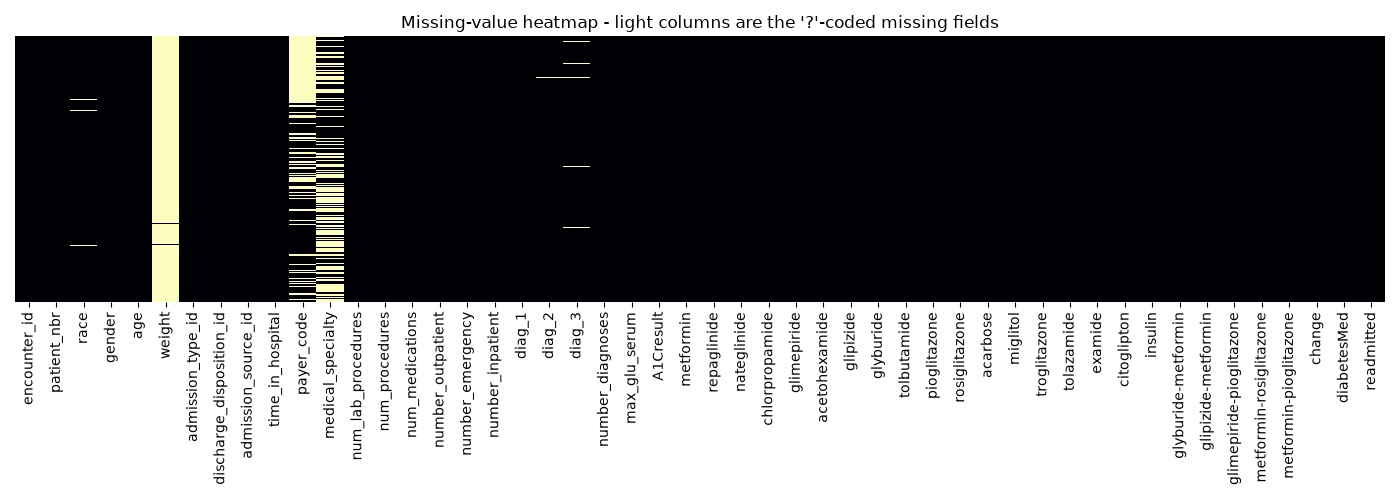

In [20]:
plt.figure(figsize=(14, 5))
sns.heatmap(data.isnull(), cbar=False, yticklabels=False, cmap="magma")
plt.title("Missing-value heatmap - light columns are the '?'-coded missing fields")
plt.tight_layout()
plt.show()

**Decision.** Drop `weight`, `medical_specialty` and `payer_code`. Keep and impute the rest: mode for `race`, and an explicit `"Missing"` category for the diagnosis columns, since a missing ICD-9 code is not well represented by the most common diagnosis.

### 4.2 Duplicates and entity-level recurrence

The standard check is for duplicate rows. At row level this dataset is clean.

In [21]:
exact_duplicates = data.drop(columns=["encounter_id"]).duplicated().sum()
print(f"Exact duplicate rows (excluding encounter_id): {exact_duplicates}")

Exact duplicate rows (excluding encounter_id): 0


Zero exact duplicates. The real duplication sits one level up: the same patient can contribute several encounters.

In [22]:
n_rows = len(data)
n_patients = data["patient_nbr"].nunique()
encounters_per_patient = data.groupby("patient_nbr").size()
n_multi_encounter_patients = (encounters_per_patient > 1).sum()
rows_from_multi_encounter_patients = data["patient_nbr"].map(encounters_per_patient).gt(1).sum()

print(f"Rows (encounters):                         {n_rows:,}")
print(f"Unique patients:                            {n_patients:,}")
print(f"Patients with > 1 encounter:                {n_multi_encounter_patients:,} "
      f"({n_multi_encounter_patients / n_patients * 100:.1f} % of patients)")
print(f"Rows belonging to a multi-encounter patient: {rows_from_multi_encounter_patients:,} "
      f"({rows_from_multi_encounter_patients / n_rows * 100:.1f} % of rows)")
print(f"Max encounters for a single patient:         {encounters_per_patient.max()}")

Rows (encounters):                         101,766
Unique patients:                            71,518
Patients with > 1 encounter:                16,773 (23.5 % of patients)
Rows belonging to a multi-encounter patient: 47,021 (46.2 % of rows)
Max encounters for a single patient:         40


**Decision.** There are no duplicate rows to drop, but 46.2% of rows belong to a patient who appears more than once. Left alone this becomes a leakage problem at split time - a patient's encounters could land in both train and test - so it drives the grouped split in Section 6.

### 4.3 Outliers

Detection by boxplot and histogram, the mean-versus-standard-deviation rule of thumb (outliers likely when std > mean), and the IQR rule (`LL = Q1 - 1.5*IQR`, `UL = Q3 + 1.5*IQR`).

In [23]:
# Apply the own "MEAN vs STD" heuristic to every numeric feature.
mean_std_table = data[numeric_cols].agg(["mean", "std"]).T
mean_std_table["heuristic_flags_outliers"] = mean_std_table["std"] > mean_std_table["mean"]
mean_std_table.round(3)

,mean,std,heuristic_flags_outliers
time_in_hospital,4.396,2.985,False
num_lab_procedures,43.096,19.674,False
num_procedures,1.340,1.706,True
num_medications,16.022,8.128,False
number_outpatient,0.369,1.267,True
number_emergency,0.198,0.930,True
number_inpatient,0.636,1.263,True
number_diagnoses,7.423,1.934,False


`number_emergency` has mean 0.198 < std 0.930, so the rule of thumb flags it. The same holds for `number_outpatient` and `number_inpatient` - all three are sparse, right-skewed visit counts where most patients have zero.

In [24]:
# The exact IQR method for the same set of numeric features.
iqr_rows = []
for col in numeric_cols:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    ll, ul = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_below, n_above = (data[col] < ll).sum(), (data[col] > ul).sum()
    iqr_rows.append([col, q1, q3, iqr, ll, ul, n_below, n_above])

iqr_table = pd.DataFrame(
    iqr_rows, columns=["feature", "Q1", "Q3", "IQR", "LL", "UL", "n_below_LL", "n_above_UL"]
).set_index("feature")
iqr_table.round(2)

,Q1,Q3,IQR,LL,UL,n_below_LL,n_above_UL
feature,,,,,,,
time_in_hospital,2.0,6.0,4.0,-4.0,12.0,0,2252
num_lab_procedures,31.0,57.0,26.0,-8.0,96.0,0,143
num_procedures,0.0,2.0,2.0,-3.0,5.0,0,4954
num_medications,10.0,20.0,10.0,-5.0,35.0,0,2557
number_outpatient,0.0,0.0,0.0,0.0,0.0,0,16739
number_emergency,0.0,0.0,0.0,0.0,0.0,0,11383
number_inpatient,0.0,1.0,1.0,-1.5,2.5,0,7049
number_diagnoses,6.0,9.0,3.0,1.5,13.5,219,62


**Decision.** Keep all values. These are counts of clinical events, not continuous measurements: a patient with six emergency visits is a genuine high-utiliser, exactly the case a readmission model should learn from, not a data-entry error. The skew is handled by `StandardScaler` after the split, never by removal.

### 4.4 Incorrect / inconsistent data

Invalid category levels and identifiers stored as integers - two issues here.

In [25]:
data["gender"].value_counts(dropna=False)

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [26]:
# admission_type_id / discharge_disposition_id / admission_source_id are nominal category codes stored as plain
data[["admission_type_id", "discharge_disposition_id", "admission_source_id"]].describe()

,admission_type_id,discharge_disposition_id,admission_source_id
count,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437
std,1.445403,5.280166,4.064081
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,7.000000
75%,3.000000,4.000000,7.000000
max,8.000000,28.000000,25.000000


**Decision.** `gender` has 3 rows of `'Unknown/Invalid'`, too few to impute and clinically ambiguous, so they are removed. The three ID columns are decoded via `IDS_mapping.csv` into text descriptions and treated as nominal categoricals rather than left as integers a model might read as ordinal.

### 4.5 Constant and near-constant features

A feature with (near-)zero variance carries almost no information and can be dropped.

In [27]:
# The most-frequent-category share for every medication column - a quick way to surface
# both the fully-constant and the near-constant columns in one table.
medication_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
top_share = data[medication_cols].apply(lambda s: s.value_counts(normalize=True).iloc[0])
top_share.sort_values(ascending=False).to_frame("top_category_share")

,top_category_share
citoglipton,1.000000
examide,1.000000
acetohexamide,0.999990
metformin-pioglitazone,0.999990
glimepiride-pioglitazone,0.999990
metformin-rosiglitazone,0.999980
troglitazone,0.999971
glipizide-metformin,0.999872
tolbutamide,0.999774
miglitol,0.999627


**Decision (two cases, handled differently).** `examide` and `citoglipton` are exactly 100% one value - zero information under any split - so they are dropped before the split. The ~13 near-constant (>=99%) medication columns involve a data-driven threshold, so they go through `VarianceThreshold` fit on the training fold only, after the split.

### 4.6 High-cardinality categoricals

One-hot encoding hundreds of distinct ICD-9 codes per column would blow up the input width for little signal, while ordinal-coding an unordered category imposes a false order.

In [28]:
high_cardinality_cols = ["diag_1", "diag_2", "diag_3", "medical_specialty", "payer_code"]
data[high_cardinality_cols].nunique()

diag_1               716
diag_2               748
diag_3               789
medical_specialty     72
payer_code            17
dtype: int64

**Decision.** `medical_specialty` and `payer_code` are already dropped (Section 4.1). For `diag_1/2/3` (717/749/790 distinct codes) we keep two representations: a grouping into ~9 standard clinical categories (Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other) for the dense/CNN path, and the raw code, ordinal-coded, for the embedding path of Model A in the next notebook.

### 4.7 Target-variable noise

`discharge_disposition_id` includes expired and hospice dispositions (codes 11, 13, 14, 19, 20, 21). A patient under any of these cannot be readmitted by definition, so their `'NO'` label is a structural artefact rather than a real outcome.

In [29]:
expired_hospice_ids = [11, 13, 14, 19, 20, 21]
n_expired_hospice = data["discharge_disposition_id"].isin(expired_hospice_ids).sum()
print(f"Rows with an expired/hospice discharge disposition: {n_expired_hospice:,} "
      f"({n_expired_hospice / len(data) * 100:.2f} % of rows)")

Rows with an expired/hospice discharge disposition: 2,423 (2.38 % of rows)


**Decision.** Remove these 2,423 rows.

### 4.8 Class imbalance

Established in Section 3.3: 11.16% positive.

**Decision.** No resampling in this notebook. Resampling changes the training distribution, so it is a learn-from-data operation that must happen after the split and inside the training fold; it is deferred entirely to the modelling notebook.

## 5. Cleaning before the split

Everything in this section uses only domain knowledge or fixed rules - dropping named columns, removing impossible labels, decoding a code table, mapping age bins to midpoints, grouping ICD-9 codes. None of it depends on a statistic computed from the data, so it is safe to do before the split. Anything that learns from data (imputation, scaling, encoding, variance filtering, resampling) is deferred to Section 7.

**Drop irrelevant, constant and >30%-missing columns**

- `encounter_id` - an identifier, not a predictor.
- `examide`, `citoglipton` - 100% constant.
- `weight`, `medical_specialty`, `payer_code` - over 30% missing.

In [30]:
data_before_shape = data.shape

columns_to_drop = ["encounter_id", "examide", "citoglipton", "weight", "medical_specialty", "payer_code"]
data = data.drop(columns=columns_to_drop)
print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
data.shape

Dropped 6 columns: ['encounter_id', 'examide', 'citoglipton', 'weight', 'medical_specialty', 'payer_code']


(101766, 44)

**Remove target-variable-noise rows (expired / hospice discharges)** - see Section 4.7.

In [31]:
expired_hospice_ids = [11, 13, 14, 19, 20, 21]
n_before = len(data)
data = data[~data["discharge_disposition_id"].isin(expired_hospice_ids)].copy()
print(f"Removed {n_before - len(data):,} expired/hospice rows -> {len(data):,} rows remain")

Removed 2,423 expired/hospice rows -> 99,343 rows remain


**Remove invalid category rows (`gender = 'Unknown/Invalid'`)** - see Section 4.4.

In [32]:
n_before = len(data)
data = data[data["gender"] != "Unknown/Invalid"].copy()
print(f"Removed {n_before - len(data)} rows with gender = 'Unknown/Invalid' -> {len(data):,} rows remain")

Removed 3 rows with gender = 'Unknown/Invalid' -> 99,340 rows remain


**Basic type conversion: `age` bins to numeric midpoints**

`age` is stored as 10-year bin strings (`'[70-80)'`). Each bin is mapped to its midpoint - a fixed mapping, not learned from data, so it belongs before the split.

In [33]:
age_bin_to_midpoint = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
    "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95,
}
data["age"] = data["age"].map(age_bin_to_midpoint)
data["age"].value_counts().sort_index()

age
5       160
15      690
25     1649
35     3764
45     9607
55    17060
65    22058
75    25329
85    16434
95     2589
Name: count, dtype: int64

**Decode the three nominal-stored-as-integer ID columns via `IDS_mapping.csv`**

`IDS_mapping.csv` packs three lookup tables into one file separated by blank rows; it is split into three `{id: description}` dictionaries below.

In [34]:
with open(DATA_DIR / "IDS_mapping.csv") as f:
    raw_lines = f.readlines()

# The three lookup tables are separated by a row that is just a bare comma.
separator_idx = [i for i, line in enumerate(raw_lines) if line.strip() in ("", ",")]
table_bounds = [0] + [i + 1 for i in separator_idx] + [len(raw_lines)]
table_names = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]

id_maps = {}
for name, start, end in zip(table_names, table_bounds[:-1], table_bounds[1:]):
    chunk_lines = [ln for ln in raw_lines[start:end] if ln.strip() not in ("", ",")]
    lookup_table = pd.read_csv(StringIO("".join(chunk_lines)))
    id_maps[name] = dict(zip(lookup_table[name], lookup_table["description"]))

{name: len(mapping) for name, mapping in id_maps.items()}

{'admission_type_id': 8,
 'discharge_disposition_id': 30,
 'admission_source_id': 25}

In [35]:
# Replace each numeric code with its decoded description, then drop the now-redundant
# numeric id column - the description is the nominal category we one-hot encode later.
for id_col, description_col in [
    ("admission_type_id", "admission_type"),
    ("discharge_disposition_id", "discharge_disposition"),
    ("admission_source_id", "admission_source"),
]:
    data[description_col] = data[id_col].map(id_maps[id_col])

data = data.drop(columns=["admission_type_id", "discharge_disposition_id", "admission_source_id"])
data[["admission_type", "discharge_disposition", "admission_source"]].nunique()

admission_type            7
discharge_disposition    20
admission_source         16
dtype: int64

**Group the ICD-9 diagnosis codes into clinical categories, keeping the raw code**

Boundaries follow the grouping used in the original study of this dataset (Strack et al., 2014): Circulatory (390-459, 785), Respiratory (460-519, 786), Digestive (520-579, 787), Diabetes (250.xx), Injury (800-999), Musculoskeletal (710-739), Genitourinary (580-629, 788), Neoplasms (140-239), else Other. `V`/`E`-prefixed and unmapped codes fall into Other.

In [36]:
def icd9_to_category(code) -> str:
    """Map a raw ICD-9-CM code string to one of the standard clinical categories."""
    if pd.isna(code):
        return "Missing"
    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "Other"
    try:
        value = float(code)
    except ValueError:
        return "Other"
    if 390 <= value <= 459 or value == 785:
        return "Circulatory"
    if 460 <= value <= 519 or value == 786:
        return "Respiratory"
    if 520 <= value <= 579 or value == 787:
        return "Digestive"
    if 250 <= value < 251:
        return "Diabetes"
    if 800 <= value <= 999:
        return "Injury"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if 580 <= value <= 629 or value == 788:
        return "Genitourinary"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"

for diag_col in ["diag_1", "diag_2", "diag_3"]:
    data[f"{diag_col}_category"] = data[diag_col].apply(icd9_to_category)
    # Raw code retained as its own column (with missing codes made an explicit 'Missing'
    # string) for the embedding path used by Model A.
    data[diag_col] = data[diag_col].fillna("Missing")

data[["diag_1_category", "diag_2_category", "diag_3_category"]].apply(pd.Series.value_counts)

,diag_1_category,diag_2_category,diag_3_category
Circulatory,29680,31157,29599
Diabetes,8661,12705,16979
Digestive,9333,4088,3857
Genitourinary,5002,8147,6436
Injury,6851,2383,1897
Missing,20,356,1419
Musculoskeletal,4935,1761,1898
Neoplasms,3131,2326,1662
Other,17793,26027,28588
Respiratory,13934,10390,7005


**Build the binary target**

In [37]:
data["readmitted_30d"] = (data["readmitted"] == "<30").astype(int)
data = data.drop(columns=["readmitted"])

print(data["readmitted_30d"].value_counts())
print((data["readmitted_30d"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

readmitted_30d
0    88026
1    11314
Name: count, dtype: int64
readmitted_30d
0    88.61 %
1    11.39 %
Name: proportion, dtype: str


In [38]:
data_after_shape = data.shape
print(f"Shape before Section 5 cleaning: {data_before_shape}")
print(f"Shape after  Section 5 cleaning: {data_after_shape}")

Shape before Section 5 cleaning: (101766, 50)
Shape after  Section 5 cleaning: (99340, 47)


## 6. Data Split - grouped and stratified

46.2% of rows belong to a patient with more than one encounter, so a plain row-level split would let a patient appear in both train and test. We first measure how large that leak would be, then build the grouped, stratified split actually used.

**Naive random split (for comparison only - not used downstream)**

In [39]:
x_naive = data.drop(columns=["readmitted_30d"])
y_naive = data["readmitted_30d"]

# Naive random split, stratified on the target (for the leakage comparison only).

x_train_naive, x_test_naive, y_train_naive, y_test_naive = train_test_split(
    x_naive, y_naive, test_size=0.2, stratify=y_naive, random_state=RANDOM_STATE,
)

train_patients_naive = set(x_train_naive["patient_nbr"])
test_patients_naive = set(x_test_naive["patient_nbr"])
leaked_patients_naive = train_patients_naive & test_patients_naive

n_test_rows_with_sibling = x_test_naive["patient_nbr"].isin(leaked_patients_naive).sum()

naive_leakage_table = pd.DataFrame(
    {
        "metric": [
            "Patients in naive train set",
            "Patients in naive test set",
            "Patients appearing in BOTH (leaked)",
            "Test rows with a sibling encounter in train",
        ],
        "value": [
            len(train_patients_naive),
            len(test_patients_naive),
            len(leaked_patients_naive),
            n_test_rows_with_sibling,
        ],
    }
)
naive_leakage_table["pct_of_test"] = [
    np.nan, np.nan,
    round(len(leaked_patients_naive) / len(test_patients_naive) * 100, 2),
    round(n_test_rows_with_sibling / len(x_test_naive) * 100, 2),
]
naive_leakage_table

,metric,value,pct_of_test
0,Patients in naive train set,58847,NaN
1,Patients in naive test set,17895,NaN
2,Patients appearing in BOTH (leaked),6755,37.75
3,Test rows with a sibling encounter in train,8268,41.61


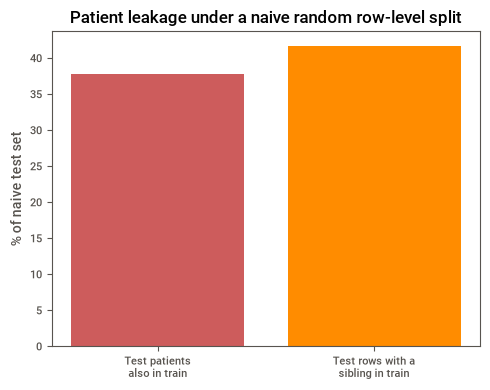

In [40]:
plt.figure(figsize=(5, 4))
plt.bar(
    ["Test patients\nalso in train", "Test rows with a\nsibling in train"],
    [
        len(leaked_patients_naive) / len(test_patients_naive) * 100,
        n_test_rows_with_sibling / len(x_test_naive) * 100,
    ],
    color=["indianred", "darkorange"],
)
plt.ylabel("% of naive test set")
plt.title("Patient leakage under a naive random row-level split")
plt.tight_layout()
plt.show()

Under the naive split a large share of test rows share a patient with training data, so they are not genuinely unseen. This is a pure data fact; its effect on a reported score is measured in the modelling notebook. `x_train_naive`/`x_test_naive` are used only for this comparison.

**Grouped, stratified split - the split actually used**

`StratifiedGroupKFold` keeps whole patients together while preserving class balance as far as the grouping allows. Nested 5-way then 4-way folds give roughly a 60/20/20 train/validation/test split.

In [41]:
x_all = data.drop(columns=["readmitted_30d"])
y_all = data["readmitted_30d"]
groups_all = data["patient_nbr"]

# Step 1: carve out the test fold (20 %), grouped on patient_nbr and stratified on the target.
splitter_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(splitter_test.split(x_all, y_all, groups_all))

# Step 2: split the remaining 80 % again (1/4 = 20 % of the ORIGINAL data -> validation).
x_train_val, y_train_val, groups_train_val = (
    x_all.iloc[train_val_idx], y_all.iloc[train_val_idx], groups_all.iloc[train_val_idx],
)
splitter_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
train_idx_local, val_idx_local = next(splitter_val.split(x_train_val, y_train_val, groups_train_val))

train_idx = train_val_idx[train_idx_local]
val_idx = train_val_idx[val_idx_local]

x_train, y_train = x_all.iloc[train_idx].reset_index(drop=True), y_all.iloc[train_idx].reset_index(drop=True)
x_val, y_val = x_all.iloc[val_idx].reset_index(drop=True), y_all.iloc[val_idx].reset_index(drop=True)
x_test, y_test = x_all.iloc[test_idx].reset_index(drop=True), y_all.iloc[test_idx].reset_index(drop=True)

print(f"train: {x_train.shape}, val: {x_val.shape}, test: {x_test.shape}")

train: (59605, 46), val: (19868, 46), test: (19867, 46)


In [42]:
# Verify the grouping constraint actually holds: no patient_nbr appears in more than one split.
train_patients = set(x_train["patient_nbr"])
val_patients = set(x_val["patient_nbr"])
test_patients = set(x_test["patient_nbr"])

assert not (train_patients & val_patients), "Patient overlap between train and validation!"
assert not (train_patients & test_patients), "Patient overlap between train and test!"
assert not (val_patients & test_patients), "Patient overlap between validation and test!"
print("Confirmed: zero patient overlap across train / validation / test.")

Confirmed: zero patient overlap across train / validation / test.


In [43]:
split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "n_rows": [len(x_train), len(x_val), len(x_test)],
        "n_patients": [len(train_patients), len(val_patients), len(test_patients)],
        "positive_rate_pct": [
            round(y_train.mean() * 100, 2),
            round(y_val.mean() * 100, 2),
            round(y_test.mean() * 100, 2),
        ],
    }
)
split_summary

,split,n_rows,n_patients,positive_rate_pct
0,train,59605,42043,11.39
1,validation,19868,13993,11.39
2,test,19867,13951,11.39


Class balance stays close to 11.16% in each split. Some deviation is expected under grouping, since a patient can only sit in one split, and it is reported here rather than hidden.

## 7. Preprocessing after the split - fit on train only

Every operation below learns something from the data - a mean, a standard deviation, a set of categories, a variance - so each is fit on the training fold only and merely applied to validation and test. Fitting on the full data would leak test information into those statistics and inflate the reported score.

No resampling happens here. It belongs inside the training fold of the modelling notebook, not at the dataset level, because resampling before the split is exactly what inflates published scores on this dataset.

**Feature lists**

In [44]:
# Drop patient_nbr - it was only ever a grouping key for the split, never a model feature.
x_train_f = x_train.drop(columns=["patient_nbr"])
x_val_f = x_val.drop(columns=["patient_nbr"])
x_test_f = x_test.drop(columns=["patient_nbr"])

numeric_features = [
    "age", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
]

medication_features = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]

categorical_features = [
    "race", "gender", "admission_type", "discharge_disposition", "admission_source",
    "max_glu_serum", "A1Cresult", "change", "diabetesMed",
    "diag_1_category", "diag_2_category", "diag_3_category",
] + medication_features

diag_code_features = ["diag_1", "diag_2", "diag_3"]

print(f"{len(numeric_features)} numeric, {len(categorical_features)} low-cardinality "
      f"categorical, {len(diag_code_features)} high-cardinality diagnosis-code features")

9 numeric, 33 low-cardinality categorical, 3 high-cardinality diagnosis-code features


**Impute + encode + scale the numeric / low-cardinality-categorical block**

Numeric: mean-impute then `StandardScaler`. Categorical: most-frequent impute then `OneHotEncoder(handle_unknown='ignore')`, so an unseen category becomes an all-zero row rather than an error. Both are wrapped in one `ColumnTransformer`, fit once on the training data.

In [45]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

# Fit on the TRAINING fold only...
x_train_dense = preprocessor.fit_transform(x_train_f[numeric_features + categorical_features])
# ... then only TRANSFORM validation and test - they never influence the fitted statistics.
x_val_dense = preprocessor.transform(x_val_f[numeric_features + categorical_features])
x_test_dense = preprocessor.transform(x_test_f[numeric_features + categorical_features])

dense_feature_names = preprocessor.get_feature_names_out()
print(f"Encoded dense width before variance filtering: {x_train_dense.shape[1]}")

Encoded dense width before variance filtering: 164


**Variance Threshold - drop near-constant one-hot columns, fit on train only**

The ~13 near-constant medication columns from Section 4.5 are removed here, on the encoded training matrix only.

In [46]:
variance_selector = VarianceThreshold(threshold=0.01)
x_train_dense = variance_selector.fit_transform(x_train_dense)
x_val_dense = variance_selector.transform(x_val_dense)
x_test_dense = variance_selector.transform(x_test_dense)

kept_mask = variance_selector.get_support()
dense_feature_names_kept = dense_feature_names[kept_mask]
dropped_by_variance = dense_feature_names[~kept_mask]

print(f"Dropped {len(dropped_by_variance)} near-constant encoded columns "
      f"(threshold = 0.01), {x_train_dense.shape[1]} remain.")
dropped_by_variance

Dropped 75 near-constant encoded columns (threshold = 0.01), 89 remain.


array(['categorical__race_Asian', 'categorical__admission_type_Newborn',
       'categorical__admission_type_Not Mapped',
       'categorical__admission_type_Trauma Center',
       'categorical__discharge_disposition_Admitted as an inpatient to this hospital',
       'categorical__discharge_disposition_Discharged/transferred to ICF',
       'categorical__discharge_disposition_Discharged/transferred to a federal health care facility.',
       'categorical__discharge_disposition_Discharged/transferred to a long term care hospital.',
       'categorical__discharge_disposition_Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.',
       'categorical__discharge_disposition_Discharged/transferred to home under care of Home IV provider',
       'categorical__discharge_disposition_Discharged/transferred within this institution to Medicare approved swing bed',
       'categorical__discharge_disposition_Discharged/transferred/referred another i

**Reading the dropped list.** `VarianceThreshold` runs on the one-hot matrix, so a near-constant medication column drops all of its levels together (for example the four `nateglinide_*` columns). It also prunes individually rare levels of otherwise useful features (`race_Asian`, a few rare discharge and admission levels), because a per-column variance cannot tell a near-constant feature from a rare level of a good one. The trade is a smaller, faster feature space at the cost of some resolution on rare levels; grouping rare levels into an `'Other'` bucket before encoding would recover them.

**Ordinal-code the high-cardinality diagnosis columns for the embedding path**

Each `diag_*` column gets its own `OrdinalEncoder` fit on training codes, with one reserved index for codes seen only in validation/test, so the embedding layer has a defined bucket for unknown codes.

In [47]:
diag_encoders = {}
diag_vocab_sizes = {}

for col in diag_code_features:
    n_known_categories = x_train_f[col].nunique()
    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=n_known_categories,  # one reserved index for codes unseen in training
        dtype=np.int32,
    )
    encoder.fit(x_train_f[[col]])
    diag_encoders[col] = encoder
    diag_vocab_sizes[col] = int(n_known_categories) + 1

x_train_diag_idx = np.hstack([diag_encoders[c].transform(x_train_f[[c]]) for c in diag_code_features])
x_val_diag_idx = np.hstack([diag_encoders[c].transform(x_val_f[[c]]) for c in diag_code_features])
x_test_diag_idx = np.hstack([diag_encoders[c].transform(x_test_f[[c]]) for c in diag_code_features])

diag_vocab_sizes

{'diag_1': 671, 'diag_2': 682, 'diag_3': 733}

In [48]:
x_train_dense = x_train_dense.astype("float32")
x_val_dense = x_val_dense.astype("float32")
x_test_dense = x_test_dense.astype("float32")

print("Final encoded shapes:")
print(f"  dense/CNN path   -> train {x_train_dense.shape}, val {x_val_dense.shape}, test {x_test_dense.shape}")
print(f"  diag-index path  -> train {x_train_diag_idx.shape}, val {x_val_diag_idx.shape}, test {x_test_diag_idx.shape}")
print(f"  target           -> train {y_train.shape}, val {y_val.shape}, test {y_test.shape}")

Final encoded shapes:
  dense/CNN path   -> train (59605, 89), val (19868, 89), test (19867, 89)
  diag-index path  -> train (59605, 3), val (19868, 3), test (19867, 3)
  target           -> train (59605,), val (19868,), test (19867,)


## 8. Save artifacts

The encoded arrays, the fitted transformers (so validation/test are always regenerated from the same fit) and a JSON manifest of shapes, class balance and feature lists are written to `artifacts/` for the modelling notebooks.

In [49]:
# Encoded arrays
np.save(ARTIFACTS_DIR / "x_train_dense.npy", x_train_dense)
np.save(ARTIFACTS_DIR / "x_val_dense.npy", x_val_dense)
np.save(ARTIFACTS_DIR / "x_test_dense.npy", x_test_dense)

np.save(ARTIFACTS_DIR / "x_train_diag_idx.npy", x_train_diag_idx)
np.save(ARTIFACTS_DIR / "x_val_diag_idx.npy", x_val_diag_idx)
np.save(ARTIFACTS_DIR / "x_test_diag_idx.npy", x_test_diag_idx)

np.save(ARTIFACTS_DIR / "y_train.npy", y_train.to_numpy())
np.save(ARTIFACTS_DIR / "y_val.npy", y_val.to_numpy())
np.save(ARTIFACTS_DIR / "y_test.npy", y_test.to_numpy())

print("Saved encoded arrays to artifacts/")

Saved encoded arrays to artifacts/


In [50]:
# Fitted transformers (joblib)
joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor.joblib")
joblib.dump(variance_selector, ARTIFACTS_DIR / "variance_selector.joblib")
joblib.dump(diag_encoders, ARTIFACTS_DIR / "diag_encoders.joblib")

print("Saved fitted transformers to artifacts/")

Saved fitted transformers to artifacts/


In [51]:
# JSON manifest
manifest = {
    "random_state": RANDOM_STATE,
    "shapes": {
        "dense_path": {
            "x_train": list(x_train_dense.shape),
            "x_val": list(x_val_dense.shape),
            "x_test": list(x_test_dense.shape),
        },
        "diag_index_path": {
            "x_train": list(x_train_diag_idx.shape),
            "x_val": list(x_val_diag_idx.shape),
            "x_test": list(x_test_diag_idx.shape),
        },
    },
    "class_balance_positive_rate_pct": {
        "train": round(float(y_train.mean()) * 100, 2),
        "val": round(float(y_val.mean()) * 100, 2),
        "test": round(float(y_test.mean()) * 100, 2),
    },
    "n_patients": {
        "train": len(train_patients),
        "val": len(val_patients),
        "test": len(test_patients),
    },
    "naive_split_leakage": {
        "test_patients_also_in_train": len(leaked_patients_naive),
        "pct_test_patients_leaked": round(len(leaked_patients_naive) / len(test_patients_naive) * 100, 2),
        "test_rows_with_sibling_in_train": int(n_test_rows_with_sibling),
        "pct_test_rows_with_sibling": round(n_test_rows_with_sibling / len(x_test_naive) * 100, 2),
    },
    "feature_lists": {
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "diag_code_features": diag_code_features,
        "dense_features_kept": dense_feature_names_kept.tolist(),
        "dense_features_dropped_by_variance_threshold": dropped_by_variance.tolist(),
    },
    "diag_vocab_sizes": diag_vocab_sizes,
    "split_method": "StratifiedGroupKFold, grouped on patient_nbr, approx. 60/20/20 train/val/test",
}

with open(ARTIFACTS_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Manifest written to {ARTIFACTS_DIR / 'manifest.json'}")
print(json.dumps(manifest["shapes"], indent=2))

Manifest written to artifacts/manifest.json
{
  "dense_path": {
    "x_train": [
      59605,
      89
    ],
    "x_val": [
      19868,
      89
    ],
    "x_test": [
      19867,
      89
    ]
  },
  "diag_index_path": {
    "x_train": [
      59605,
      3
    ],
    "x_val": [
      19868,
      3
    ],
    "x_test": [
      19867,
      3
    ]
  }
}


## 9. Summary

| # | Decision | Effect on the data |
|---|---|---|
| 1 | Re-read with `na_values='?'` | Surfaces 192,849 hidden missing cells across 7 columns |
| 2 | Drop `weight`, `medical_specialty`, `payer_code` (>30% missing) | 50 -> 47 columns |
| 3 | Drop `encounter_id` (identifier) | 47 -> 46 columns |
| 4 | Drop `examide`, `citoglipton` (100% constant) | 46 -> 44 columns |
| 5 | Remove 2,423 expired/hospice rows | 101,766 -> 99,343 rows |
| 6 | Remove 3 `gender='Unknown/Invalid'` rows | 99,343 -> 99,340 rows |
| 7 | Map `age` bins to midpoints | `age` becomes numeric |
| 8 | Decode the three ID columns via `IDS_mapping.csv` | integer codes -> text categories |
| 9 | Group ICD-9 `diag_1/2/3` into ~9 categories, keep raw code | adds a category column per diagnosis |
| 10 | Build binary `readmitted_30d` | 11.16% positive |
| 11 | Grouped, stratified ~60/20/20 split on `patient_nbr` | zero patient overlap across splits |
| 12 | Impute, one-hot, scale - fit on train only | numerics standardised, categoricals expanded |
| 13 | `VarianceThreshold` on the encoded train matrix | drops near-constant one-hot columns |
| 14 | Ordinal-code `diag_1/2/3`, fit on train only | 3 integer-index arrays with an unknown bucket |
| 15 | No resampling here | deferred to the training fold in the modelling notebook |

Final shapes and class balance are in the manifest above; no patient spans more than one split.